## Analyze only the users, not the admins.
Create two lists of values for the histogram input: one for working days and one for weekends.
The fig size remains the same. You can also choose the font size and color palette.
Use a level of transparency equal to 0.7 for the histogram in front.
At the end of your Jupyter Notebook, create a Markdown cell and insert the following question: "Are there hours when the total number of commits was higher on weekends than on working days?" In your answer, include the top four examples.

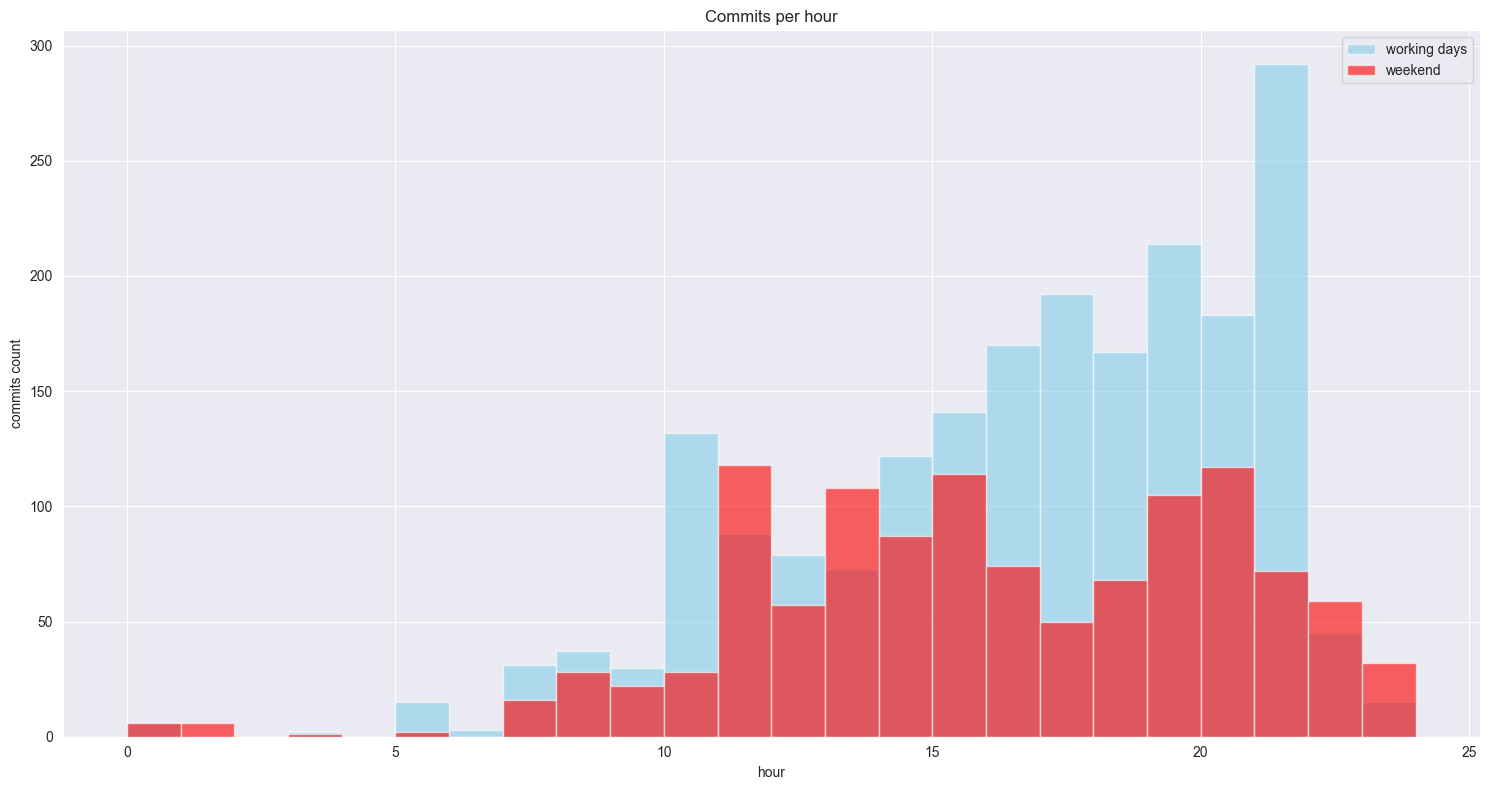

In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
conn  = sqlite3.connect('../data/checking-logs.sqlite')

query = """
SELECT 
timestamp AS date
FROM checker
WHERE uid LIKE 'user_%'
"""

all_days = pd.read_sql_query(query, conn)
all_days['date']= pd.to_datetime(all_days['date'])
all_days['hour'] = all_days['date'].dt.hour
all_days['week_day'] = all_days['date'].dt.weekday

all_days['day_type'] = all_days['week_day'].apply(lambda x: 'weekend' if x >=5 else 'working_day')
result = all_days

hours_work = all_days.loc[all_days['day_type'] == 'working_day', 'hour']
hours_weekend = all_days.loc[all_days['day_type'] == 'weekend', 'hour']
plt.figure(figsize=(15, 8))

plt.hist(
    hours_work,
    bins=24,
    range=(0, 24),
    alpha=0.6,
    color='skyblue',
    label='working days'
)

plt.hist(
    hours_weekend,
    bins=24,
    range=(0, 24),
    alpha=0.6,
    color='red',
    label='weekend'
)

plt.xlabel('hour')
plt.ylabel('commits count')
plt.title('Commits per hour')
plt.legend()
plt.tight_layout()
plt.show()

conn.close()

## Бывали ли часы, когда общее количество коммитов было выше в выходные дни, чем в рабочие дни?

Ответ: да, это можно ярко наблюдать на 12,14,23,24-ом часу